Creating dataframes

In [37]:
import pandas as pd
import numpy as np

#frequency matrix
F = pd.DataFrame({'S1': [0, 0, 8, 0],'S2': [0, 0, 5, 0],'M1': [8, 5, 0, 6],'C1': [0, 0, 6, 0]}, index=['S1', 'S2', 'M1', 'C1'])

TT = {('S1', 'M1'): [18*60 + 35, 21*60 + 27, 19*60 + 46, 26*60 + 25, 28*60 + 36, 20*60 + 28, 32*60 + 16, 22*60 + 10],('S2', 'M1'): [16*60 + 25, 19*60 + 38, 20*60 + 56, 9*60 + 13, 12*60 + 8],
('M1', 'C1'): [3*60 + 42, 2*60 + 56, 4*60 + 15, 3*60 + 18, 5*60 + 8, 3*60 + 50]}

#departure time matrix
DEP = {('S1', 'M1'): [16*60 + 30, 14*60 + 40, 3*60 + 55, 1*60 + 25, 10*60 + 26, 12*60 + 25, 6*60 + 35, 20*60 + 15],('M1', 'S1'): [18*60 + 25, 6*60 + 20, 2*60 + 25, 5*60 + 15, 9*60 + 20, 15*60 + 15, 20*60 + 18, 22*60 + 20],
('S2', 'M1'): [4*60 + 20, 8*60 + 35, 12*60 + 15, 18*60 + 12, 22*60 + 18],('M1', 'S2'): [12*60 + 25, 15*60 + 16, 18*60 + 21, 7*60 + 25, 21*60 + 20],('M1', 'C1'): [5*60 + 50, 10*60 + 25, 12*60 + 30, 18*60 + 15, 21*60 + 5, 16*60 + 20],
('C1', 'M1'): [4*60 + 0, 7*60 + 15, 10*60 + 55, 18*60 + 35, 21*60 + 25, 23*60 + 50]}

# Define a function to calculate arrival times
def calculate_arrival_times(dep_times, travel_times):
    arrival_times = []
    for dep, travel in zip(dep_times, travel_times):
        arr = (dep + travel) % (24 * 60)
        arrival_times.append(arr)
    return arrival_times


ARR = {key: calculate_arrival_times(DEP[key], TT[key]) for key in TT}

def convert_to_time_format(time_in_minutes):
    hours = time_in_minutes // 60
    minutes = time_in_minutes % 60
    return f'{int(hours):02d}:{int(minutes):02d}'

for key in ARR:
    print(f"From {key[0]} to {key[1]}: ")
    dep_times_formatted = [convert_to_time_format(t) for t in DEP[key]]
    arr_times_formatted = [convert_to_time_format(t) for t in ARR[key]]

    print(df)
    print()

From S1 to M1: 
        Departure Time Arrival Time
Train 1          05:50        09:32
Train 2          10:25        13:21
Train 3          12:30        16:45
Train 4          18:15        21:33
Train 5          21:05        02:13
Train 6          16:20        20:10

From S2 to M1: 
        Departure Time Arrival Time
Train 1          05:50        09:32
Train 2          10:25        13:21
Train 3          12:30        16:45
Train 4          18:15        21:33
Train 5          21:05        02:13
Train 6          16:20        20:10

From M1 to C1: 
        Departure Time Arrival Time
Train 1          05:50        09:32
Train 2          10:25        13:21
Train 3          12:30        16:45
Train 4          18:15        21:33
Train 5          21:05        02:13
Train 6          16:20        20:10



Plot for  Feasible Trains from S1 and S2 to C1 with Minimum 1-Hour Layover




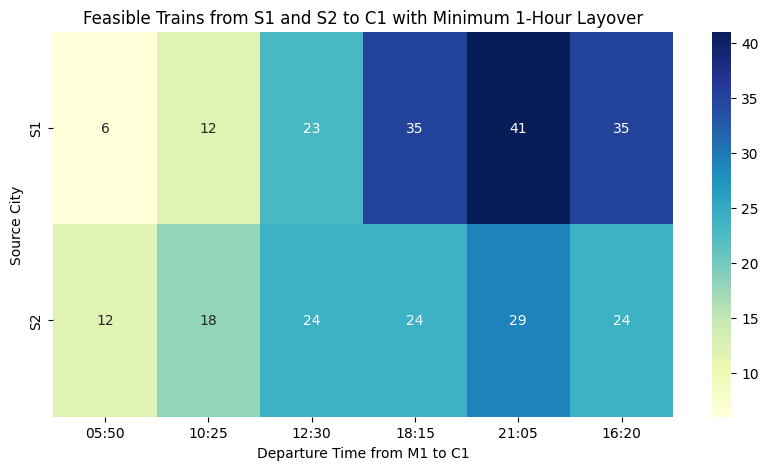

In [38]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

def find_feasible_trains(arrivals, departures, layover_min, max_total_time):
    feasible_pairs = []
    for arr in arrivals:
        for dep in departures:
            layover_time = (dep - arr) % (24 * 60)
            if layover_min <= layover_time <= max_total_time:
                feasible_pairs.append((arr, dep, layover_time))
    return feasible_pairs

# Convert times back to minutes for easier comparison
arrivals_S1_M1 = ARR[('S1', 'M1')]
arrivals_S2_M1 = ARR[('S2', 'M1')]
departures_M1_C1 = DEP[('M1', 'C1')]


layover_min = 60
max_total_time = 24 * 60

feasible_S1 = find_feasible_trains(arrivals_S1_M1, departures_M1_C1, layover_min, max_total_time)
feasible_S2 = find_feasible_trains(arrivals_S2_M1, departures_M1_C1, layover_min, max_total_time)


heatmap_data = np.zeros((2, len(departures_M1_C1)))


for i, dep in enumerate(departures_M1_C1):
    for arr, _, _ in feasible_S1:
        if dep > arr:
            heatmap_data[0, i] += 1
    for arr, _, _ in feasible_S2:
        if dep > arr:
            heatmap_data[1, i] += 1

# Plot heatmap
plt.figure(figsize=(10, 5))
sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu", xticklabels=[convert_to_time_format(t) for t in departures_M1_C1],
            yticklabels=["S1", "S2"], cbar=True)
plt.title("Feasible Trains from S1 and S2 to C1 with Minimum 1-Hour Layover")
plt.xlabel("Departure Time from M1 to C1")
plt.ylabel("Source City")
plt.show()

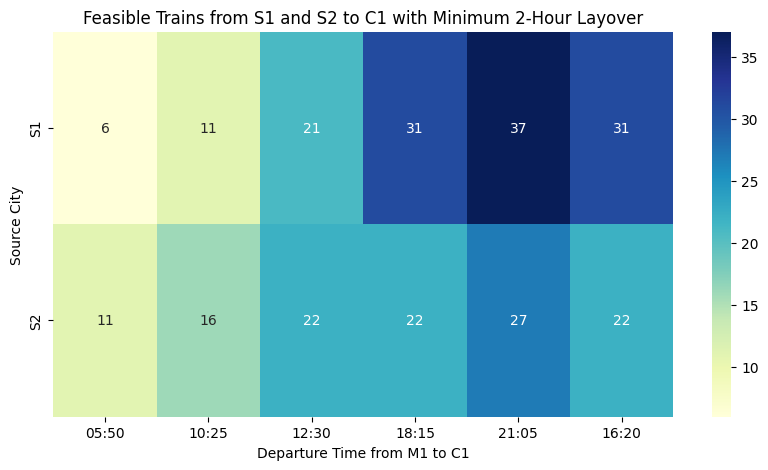

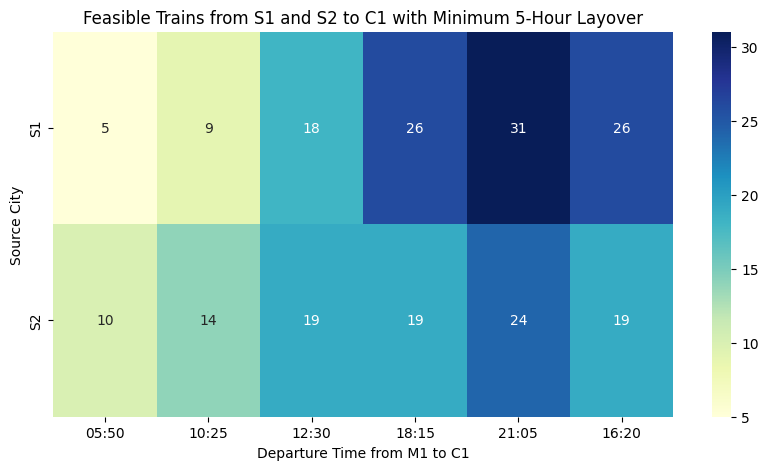

In [29]:

layover_set = [120, 300]  # 2 hours and 5 hours in minutes

feasible_S1_set = []
feasible_S2_set = []

for i in layover_set:
    feasible_S1_set.append(find_feasible_trains(arrivals_S1_M1, departures_M1_C1, i, max_total_time))
    feasible_S2_set.append(find_feasible_trains(arrivals_S2_M1, departures_M1_C1, i, max_total_time))

heatmap_data_set = []

for feasible_S1, feasible_S2 in zip(feasible_S1_set, feasible_S2_set):
    heatmap_data = np.zeros((2, len(departures_M1_C1)))
    for i, dep in enumerate(departures_M1_C1):
        for arr, _, _ in feasible_S1:
            if dep > arr:
                heatmap_data[0, i] += 1
        for arr, _, _ in feasible_S2:
            if dep > arr:
                heatmap_data[1, i] += 1
    heatmap_data_set.append(heatmap_data)

# Plot heatmaps for each layover time
for i, heatmap_data in enumerate(heatmap_data_set):
    plt.figure(figsize=(10, 5))
    sns.heatmap(heatmap_data, annot=True, cmap="YlGnBu",
                xticklabels=[convert_to_time_format(t) for t in departures_M1_C1],
                yticklabels=["S1", "S2"], cbar=True)
    plt.title(f"Feasible Trains from S1 and S2 to C1 with Minimum {layover_set[i]//60}-Hour Layover")
    plt.xlabel("Departure Time from M1 to C1")
    plt.ylabel("Source City")
    plt.show()

In [24]:

waiting_time_max = 90  # 1.5 hours in minutes
layover_min = 120  # 2 hours in minutes

# Define a function to filter based on both layover and waiting time
def find_feasible_trains_with_waiting(arrivals, departures, layover_min, waiting_time_max):
    feasible_pairs = []
    for arr in arrivals:
        for dep in departures:
            layover_time = (dep - arr) % (24 * 60)
            waiting_time = arr - min(arrivals)  # Time waited by first arriving train
            if layover_min <= layover_time <= max_total_time and waiting_time <= waiting_time_max:
                feasible_pairs.append((arr, dep, layover_time, waiting_time))
    return feasible_pairs

feasible_S1_waiting = find_feasible_trains_with_waiting(arrivals_S1_M1, departures_M1_C1, layover_min, waiting_time_max)
feasible_S2_waiting = find_feasible_trains_with_waiting(arrivals_S2_M1, departures_M1_C1, layover_min, waiting_time_max)


In [ ]:

waiting_time_max = 150  # 2.5 hours in minutes
